# MedSum-AI: Data Cleansing Pipeline
## Notebook 02 — Data Quality Enhancement (IU-CXR + CASIA-CXR)

**Following Rahm & Do (2000) taxonomy for data cleaning**

This notebook cleans **two** radiology-report datasets for downstream NLP summarisation:

| Dataset | Language | Source file | Key ID |
|---------|----------|-------------|--------|
| IU-CXR (primary) | English | `../data/iu_cxr_eda_processed.csv` | `uid` |
| CASIA-CXR (secondary) | French | `../data/casia_cxr_combined.csv` | `ExamID` |

Pipeline Steps:
1. Load raw data (both datasets)
2. Handle missing values
3. Remove duplicate reports
4. Fix data-quality issues (CASIA-CXR specific)
5. Filter malformed / truncated entries
6. Text normalisation & placeholder handling
7. Standardise column names & add dataset source tag
8. Final cleaning summary & save

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
print("Libraries loaded.")

Libraries loaded.


## Step 1: Load Raw Data

In [2]:
# ---------- IU-CXR ----------
df_iu = pd.read_csv('../data/iu_cxr_eda_processed.csv')
iu_initial = len(df_iu)

# ---------- CASIA-CXR ----------
df_ca = pd.read_csv('../data/casia_cxr_combined.csv')
ca_initial = len(df_ca)

print(f"IU-CXR   — loaded {iu_initial:,} records, {df_iu.shape[1]} columns")
print(f"CASIA-CXR — loaded {ca_initial:,} records, {df_ca.shape[1]} columns")
print()
print("IU-CXR columns:", list(df_iu.columns))
print()
print("CASIA-CXR columns:", list(df_ca.columns))

# Cleaning logs (one per dataset)
iu_log = [('Raw Input', iu_initial, 0, '-')]
ca_log = [('Raw Input', ca_initial, 0, '-')]

IU-CXR   — loaded 3,955 records, 32 columns
CASIA-CXR — loaded 13,672 records, 20 columns

IU-CXR columns: ['uid', 'pmc_id', 'filename', 'findings', 'impression', 'indication', 'comparison', 'mesh_major', 'mesh_minor', 'num_images', 'image_ids', 'findings_word_count', 'impression_word_count', 'indication_word_count', 'total_word_count', 'findings_char_count', 'impression_char_count', 'findings_sentence_count', 'impression_sentence_count', 'is_normal', 'pathology_categories', 'has_Normal', 'has_Cardiomegaly', 'has_Opacity/Mass', 'has_Atelectasis', 'has_Pleural Effusion', 'has_Pneumonia', 'has_Emphysema/COPD', 'has_Edema', 'has_xxxx', 'avg_sentence_len', 'num_pathologies']

CASIA-CXR columns: ['ExamID', 'ImageID', 'PatientID', 'ImageDir', 'StudyDate', 'PatientAge', 'PatientGender', 'PatientPosition', 'PositionView', 'Projection', 'ProjectionMethod', 'ImageWidth', 'ImageHeight', 'ReportID', 'Findings', 'Indication', 'Comparison', 'Impression', 'condition', 'dataset_source']


In [3]:
print("=== CASIA-CXR missing-value overview ===")
ca_miss = df_ca.isnull().sum()
ca_miss_pct = 100 * ca_miss / len(df_ca)
miss_df = pd.DataFrame({'missing': ca_miss, 'pct': ca_miss_pct})
print(miss_df[miss_df['missing'] > 0].sort_values('pct', ascending=False).to_string())
print()

print("=== IU-CXR missing-value overview ===")
iu_miss = df_iu[['findings', 'impression', 'indication', 'comparison']].isnull().sum()
iu_miss_pct = 100 * iu_miss / len(df_iu)
print(pd.DataFrame({'missing': iu_miss, 'pct': iu_miss_pct}).to_string())

=== CASIA-CXR missing-value overview ===
                  missing         pct
Comparison          13672  100.000000
ExamID               2561   18.731714
ReportID             2561   18.731714
PatientID            2561   18.731714
StudyDate            2561   18.731714
ImageDir             2561   18.731714
ImageWidth           2561   18.731714
ImageHeight          2561   18.731714
ProjectionMethod     2561   18.731714
PatientAge           2561   18.731714
Indication           2561   18.731714
Findings             2561   18.731714
Impression           2561   18.731714
ImageID              2560   18.724400
PositionView         2428   17.758923
Projection           2428   17.758923
PatientGender        1759   12.865711
PatientPosition      1753   12.821826

=== IU-CXR missing-value overview ===
            missing        pct
findings        530  13.400759
impression       34   0.859671
indication       90   2.275601
comparison     1198  30.290771


## Step 2: Handle Missing Values

**IU-CXR strategy** — fill empty findings/impression with `""`, then drop rows
where *both* are empty (record has no usable text).

**CASIA-CXR strategy** — drop rows where *both* Findings and Impression are
missing, fill remaining `NaN` text fields with `""`.

In [4]:
# ── IU-CXR ──────────────────────────────────────────────────────────────────
df_iu['findings']   = df_iu['findings'].fillna('')
df_iu['impression'] = df_iu['impression'].fillna('')

both_empty_iu = (df_iu['findings'] == '') & (df_iu['impression'] == '')
print(f"IU-CXR — records with BOTH findings & impression empty: {both_empty_iu.sum()}")

df_iu = df_iu[~both_empty_iu].copy()
removed = iu_initial - len(df_iu)
iu_log.append(('Drop both-empty', len(df_iu), removed, 'Missing critical text'))

findings_only   = (df_iu['findings'] != '') & (df_iu['impression'] == '')
impression_only = (df_iu['findings'] == '') & (df_iu['impression'] != '')
print(f"  findings only : {findings_only.sum()}")
print(f"  impression only: {impression_only.sum()}")
print(f"  both present  : {(~findings_only & ~impression_only).sum()}")
print(f"After missing-value handling: {len(df_iu):,} IU-CXR records")

IU-CXR — records with BOTH findings & impression empty: 28
  findings only : 6
  impression only: 502
  both present  : 3419
After missing-value handling: 3,927 IU-CXR records


In [5]:
# ── CASIA-CXR ───────────────────────────────────────────────────────────────
df_ca['Findings']   = df_ca['Findings'].fillna('')
df_ca['Impression'] = df_ca['Impression'].fillna('')
df_ca['Indication'] = df_ca['Indication'].fillna('')
df_ca['Comparison'] = df_ca['Comparison'].fillna('')

both_empty_ca = (df_ca['Findings'].str.strip() == '') & (df_ca['Impression'].str.strip() == '')
print(f"CASIA-CXR — records with BOTH Findings & Impression empty: {both_empty_ca.sum()}")

prev = len(df_ca)
df_ca = df_ca[~both_empty_ca].copy()
removed = prev - len(df_ca)
ca_log.append(('Drop both-empty', len(df_ca), removed, 'Missing critical text'))

findings_only_ca   = (df_ca['Findings'].str.strip() != '') & (df_ca['Impression'].str.strip() == '')
impression_only_ca = (df_ca['Findings'].str.strip() == '') & (df_ca['Impression'].str.strip() != '')
print(f"  findings only : {findings_only_ca.sum()}")
print(f"  impression only: {impression_only_ca.sum()}")
print(f"  both present  : {(~findings_only_ca & ~impression_only_ca).sum()}")
print(f"After missing-value handling: {len(df_ca):,} CASIA-CXR records")

CASIA-CXR — records with BOTH Findings & Impression empty: 2561
  findings only : 0
  impression only: 0
  both present  : 11111
After missing-value handling: 11,111 CASIA-CXR records


## Step 3: Remove Duplicate Reports

* **IU-CXR** — deduplicate by `uid` (exact), then TF-IDF cosine similarity > 0.95.
* **CASIA-CXR** — deduplicate by `ExamID` (exact), then check for duplicate
  Findings text (exact string match after strip).

In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# ── IU-CXR exact uid dedup ──────────────────────────────────────────────────
prev = len(df_iu)
df_iu = df_iu.drop_duplicates(subset='uid', keep='first')
uid_dups = prev - len(df_iu)
print(f"IU-CXR — exact uid duplicates removed: {uid_dups}")

# ── IU-CXR near-duplicate detection (TF-IDF cosine > 0.95) ──────────────────
df_iu['combined_text'] = df_iu['findings'].astype(str) + ' ' + df_iu['impression'].astype(str)
valid_mask = df_iu['combined_text'].str.strip() != ''
valid_texts  = df_iu.loc[valid_mask, 'combined_text'].tolist()
valid_indices = df_iu.loc[valid_mask].index.tolist()

print(f"Computing TF-IDF for {len(valid_texts):,} IU-CXR texts ...")
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_matrix = tfidf.fit_transform(valid_texts)

duplicates = set()
batch_size = 500
for i in range(0, len(valid_texts), batch_size):
    batch_end = min(i + batch_size, len(valid_texts))
    sim = cosine_similarity(tfidf_matrix[i:batch_end], tfidf_matrix)
    for row in range(batch_end - i):
        g = i + row
        for col in range(g + 1, len(valid_texts)):
            if sim[row, col] > 0.95:
                duplicates.add(valid_indices[col])

print(f"Near-duplicate records (cosine > 0.95): {len(duplicates)}")
prev = len(df_iu)
df_iu = df_iu[~df_iu.index.isin(duplicates)].copy()
removed = prev - len(df_iu)
iu_log.append(('Remove duplicates', len(df_iu), uid_dups + removed,
               f'uid exact + TF-IDF cosine > 0.95'))
print(f"After deduplication: {len(df_iu):,} IU-CXR records")

IU-CXR — exact uid duplicates removed: 0
Computing TF-IDF for 3,927 IU-CXR texts ...
Near-duplicate records (cosine > 0.95): 942
After deduplication: 2,985 IU-CXR records


In [7]:
# ── CASIA-CXR exact ExamID dedup ────────────────────────────────────────────
prev = len(df_ca)
df_ca = df_ca.drop_duplicates(subset='ExamID', keep='first')
exam_dups = prev - len(df_ca)
print(f"CASIA-CXR — exact ExamID duplicates removed: {exam_dups}")

# ── CASIA-CXR duplicate Findings text ───────────────────────────────────────
# Some exams may share identical report text (copy-paste).  Keep first occurrence.
prev = len(df_ca)
has_findings = df_ca['Findings'].str.strip() != ''
df_ca_with    = df_ca[has_findings].drop_duplicates(subset='Findings', keep='first')
df_ca_without = df_ca[~has_findings]
df_ca = pd.concat([df_ca_with, df_ca_without], ignore_index=True)
text_dups = prev - len(df_ca)
print(f"CASIA-CXR — duplicate Findings text removed: {text_dups}")

ca_log.append(('Remove duplicates', len(df_ca), exam_dups + text_dups,
               'ExamID exact + Findings text exact'))
print(f"After deduplication: {len(df_ca):,} CASIA-CXR records")

CASIA-CXR — exact ExamID duplicates removed: 0
CASIA-CXR — duplicate Findings text removed: 10422
After deduplication: 689 CASIA-CXR records


## Step 4: Fix Data-Quality Issues (CASIA-CXR specific)

Known problems discovered during EDA:
* `PatientAge` is a string (e.g. `"045Y"`) — extract numeric value.
* `PatientGender` contains numeric values such as `"74"`, `"51"` that are
  clearly mis-aligned age data — set those to `NaN`.
* `Comparison` column is 100 % `"None"` string — convert to empty string.
* General whitespace cleanup across all string columns.

In [8]:
# ── PatientAge: extract leading digits, convert to int ───────────────────────
def parse_age(val):
    if pd.isna(val) or str(val).strip() == '':
        return np.nan
    m = re.match(r'(\d+)', str(val).strip())
    if m:
        age = int(m.group(1))
        return age if 0 <= age <= 120 else np.nan
    return np.nan

df_ca['PatientAge_numeric'] = df_ca['PatientAge'].apply(parse_age)
print("PatientAge conversion:")
print(f"  valid ages : {df_ca['PatientAge_numeric'].notna().sum():,}")
print(f"  NaN / invalid: {df_ca['PatientAge_numeric'].isna().sum():,}")
if df_ca['PatientAge_numeric'].notna().any():
    print(f"  range      : {df_ca['PatientAge_numeric'].min():.0f} – "
          f"{df_ca['PatientAge_numeric'].max():.0f}")

# ── PatientGender: fix numeric values ────────────────────────────────────────
valid_genders = {'M', 'F', 'O'}
orig_gender_counts = df_ca['PatientGender'].value_counts(dropna=False)
print("\nPatientGender before fix:")
print(orig_gender_counts.head(10).to_string())

df_ca['PatientGender_clean'] = df_ca['PatientGender'].apply(
    lambda x: x.strip() if isinstance(x, str) and x.strip() in valid_genders else np.nan
)
print("\nPatientGender after fix:")
print(df_ca['PatientGender_clean'].value_counts(dropna=False).to_string())

# ── Comparison column: "None" string → empty string ─────────────────────────
none_count = (df_ca['Comparison'].astype(str).str.strip().str.lower() == 'none').sum()
print(f"\nComparison 'None' values converted to empty string: {none_count:,}")
df_ca['Comparison'] = df_ca['Comparison'].apply(
    lambda x: '' if pd.isna(x) or str(x).strip().lower() == 'none' else str(x).strip()
)

# ── Whitespace cleanup on all string columns ────────────────────────────────
str_cols = df_ca.select_dtypes(include='object').columns
for col in str_cols:
    df_ca[col] = df_ca[col].apply(
        lambda x: re.sub(r'\s+', ' ', str(x)).strip() if pd.notna(x) else x
    )
print(f"Whitespace cleaned in {len(str_cols)} string columns.")

PatientAge conversion:
  valid ages : 689
  NaN / invalid: 0
  range      : 40 – 90

PatientGender before fix:
PatientGender
M    466
F    223

PatientGender after fix:
PatientGender_clean
M    466
F    223

Comparison 'None' values converted to empty string: 0
Whitespace cleaned in 19 string columns.


## Step 5: Filter Malformed / Truncated Entries

Remove records whose report text is too short to be meaningful:
* **IU-CXR**: remove if `findings` < 3 words AND `impression` is also empty.
* **CASIA-CXR**: same logic applied to French text.

In [9]:
def word_count(text):
    return len(str(text).split()) if pd.notna(text) and str(text).strip() else 0

# ── IU-CXR ──────────────────────────────────────────────────────────────────
df_iu['_fc'] = df_iu['findings'].apply(word_count)
df_iu['_ic'] = df_iu['impression'].apply(word_count)
short_iu = (df_iu['_fc'] < 3) & (df_iu['_ic'] == 0)
print(f"IU-CXR — malformed / too-short records: {short_iu.sum()}")

if short_iu.sum() > 0:
    print(df_iu.loc[short_iu, ['uid', 'findings', 'impression']].head(5).to_string())

prev = len(df_iu)
df_iu = df_iu[~short_iu].copy()
removed = prev - len(df_iu)
iu_log.append(('Filter malformed', len(df_iu), removed, 'findings < 3 words & no impression'))
df_iu.drop(columns=['_fc', '_ic'], inplace=True)
print(f"After filtering: {len(df_iu):,} IU-CXR records")

# ── CASIA-CXR ───────────────────────────────────────────────────────────────
df_ca['_fc'] = df_ca['Findings'].apply(word_count)
df_ca['_ic'] = df_ca['Impression'].apply(word_count)
short_ca = (df_ca['_fc'] < 3) & (df_ca['_ic'] == 0)
print(f"\nCASIA-CXR — malformed / too-short records: {short_ca.sum()}")

if short_ca.sum() > 0:
    print(df_ca.loc[short_ca, ['ExamID', 'Findings', 'Impression']].head(5).to_string())

prev = len(df_ca)
df_ca = df_ca[~short_ca].copy()
removed = prev - len(df_ca)
ca_log.append(('Filter malformed', len(df_ca), removed, 'Findings < 3 words & no Impression'))
df_ca.drop(columns=['_fc', '_ic'], inplace=True)
print(f"After filtering: {len(df_ca):,} CASIA-CXR records")

IU-CXR — malformed / too-short records: 0
After filtering: 2,985 IU-CXR records

CASIA-CXR — malformed / too-short records: 0
After filtering: 689 CASIA-CXR records


## Step 6: Text Normalisation

**IU-CXR (English)**
* Lowercase
* Replace `XXXX` / `x-XXXX` placeholders
* Normalise whitespace
* Fix double periods and punctuation artefacts

**CASIA-CXR (French)**
* Preserve accented characters (é, è, ê, ë, à, â, ù, ç, etc.)
* Normalise sentence separators (`./ ` → `.\n`)
* Normalise whitespace
* Convert remaining `"None"` comparison values to empty string

In [10]:
def normalise_iu(text):
    """Clean an IU-CXR English text field."""
    if not text or pd.isna(text) or str(text).strip() == '':
        return ''
    t = str(text)
    # Lowercase
    t = t.lower()
    # Remove HTML tags (if any)
    t = re.sub(r'<[^>]+>', '', t)
    # Handle XXXX placeholders
    t = re.sub(r'\bx-xxxx\b', 'x-ray', t)
    t = re.sub(r'\bxxxx\b', '[REDACTED]', t)
    # Fix double periods
    t = re.sub(r'\.{2,}', '.', t)
    # Normalise whitespace
    t = re.sub(r'\s+', ' ', t).strip()
    # Remove leading/trailing punctuation artefacts
    t = re.sub(r'^[\s,;:.]+|[\s,;:.]+$', '', t)
    return t

# Apply
df_iu['findings_clean']   = df_iu['findings'].apply(normalise_iu)
df_iu['impression_clean']  = df_iu['impression'].apply(normalise_iu)
df_iu['indication_clean']  = df_iu['indication'].fillna('').apply(normalise_iu)

# XXXX stats
xxxx_count = df_iu['findings'].fillna('').str.contains('XXXX', case=False).sum()
print(f"IU-CXR — records with XXXX placeholders handled: {xxxx_count}")

# Show example
sample = df_iu[df_iu['findings'].fillna('').str.contains('XXXX', case=False, na=False)]
if len(sample) > 0:
    s = sample.iloc[0]
    print(f"\n  Before: {str(s['findings'])[:160]}")
    print(f"  After : {str(s['findings_clean'])[:160]}")
print(f"\nIU-CXR text normalisation complete.")

IU-CXR — records with XXXX placeholders handled: 1242

  Before: The cardiac silhouette and mediastinum size are within normal limits. There is no pulmonary edema. There is no focal consolidation. There are no XXXX of a pleur
  After : the cardiac silhouette and mediastinum size are within normal limits. there is no pulmonary edema. there is no focal consolidation. there are no [REDACTED] of a

IU-CXR text normalisation complete.


In [11]:
def normalise_casia(text):
    """Clean a CASIA-CXR French text field.
    Preserves accented characters (é, è, ê, à, â, ù, ç, etc.).
    """
    if not text or pd.isna(text) or str(text).strip() == '':
        return ''
    t = str(text)
    # Normalise sentence separators: "./" → ".\n"
    t = re.sub(r'\./', '.\n', t)
    # Collapse multiple newlines
    t = re.sub(r'\n{2,}', '\n', t)
    # Normalise whitespace within lines (preserve newlines)
    lines = t.split('\n')
    lines = [re.sub(r'[ \t]+', ' ', line).strip() for line in lines]
    t = '\n'.join(line for line in lines if line)
    # Fix double periods
    t = re.sub(r'\.{2,}', '.', t)
    # Strip leading/trailing punctuation artefacts
    t = re.sub(r'^[\s,;:.]+|[\s,;:.]+$', '', t)
    return t

# Apply
df_ca['Findings_clean']   = df_ca['Findings'].apply(normalise_casia)
df_ca['Impression_clean']  = df_ca['Impression'].apply(normalise_casia)
df_ca['Indication_clean']  = df_ca['Indication'].apply(normalise_casia)

# Show example
print("CASIA-CXR — normalisation example:")
sample_ca = df_ca[df_ca['Findings'].str.contains('./', na=False, regex=False)]
if len(sample_ca) > 0:
    s = sample_ca.iloc[0]
    print(f"\n  Before: {str(s['Findings'])[:200]}")
    print(f"  After :\n{str(s['Findings_clean'])[:200]}")
print(f"\nCASIA-CXR text normalisation complete.")

CASIA-CXR — normalisation example:

  Before: Augmentation de l’index cardio-thoracique./Absence d’anomalie parenchymateuse./Absence d’épanchement pleural./Absence d’anomalie du gril costal./Absence d’anomalie des parties molles.
  After :
Augmentation de l’index cardio-thoracique.
Absence d’anomalie parenchymateuse.
Absence d’épanchement pleural.
Absence d’anomalie du gril costal.
Absence d’anomalie des parties molles

CASIA-CXR text normalisation complete.


## Step 7: Standardise Column Names & Add Dataset Source

Map CASIA-CXR columns to a unified schema where possible so downstream
notebooks can handle both datasets consistently.

| CASIA-CXR original | Unified name |
|---------------------|-------------|
| ExamID | uid |
| Findings_clean | findings_clean |
| Impression_clean | impression_clean |
| Indication_clean | indication_clean |
| Comparison | comparison |
| condition | pathology_label |
| PatientAge_numeric | patient_age |
| PatientGender_clean | patient_gender |

Both DataFrames receive a `dataset_source` column.

In [12]:
# ── IU-CXR: add source tag ──────────────────────────────────────────────────
df_iu['dataset_source'] = 'iu_cxr'

# ── CASIA-CXR: rename + add source ──────────────────────────────────────────
ca_rename = {
    'ExamID':             'uid',
    'Findings':           'findings',
    'Impression':         'impression',
    'Indication':         'indication',
    'Comparison':         'comparison',
    'condition':          'pathology_label',
    'PatientAge_numeric': 'patient_age',
    'PatientGender_clean':'patient_gender',
    'Findings_clean':     'findings_clean',
    'Impression_clean':   'impression_clean',
    'Indication_clean':   'indication_clean',
    'ImageID':            'image_id',
    'PatientID':          'patient_id',
    'ImageDir':           'image_dir',
    'StudyDate':          'study_date',
    'PatientPosition':    'patient_position',
    'PositionView':       'position_view',
    'Projection':         'projection',
    'ProjectionMethod':   'projection_method',
    'ImageWidth':         'image_width',
    'ImageHeight':        'image_height',
    'ReportID':           'report_id',
}
df_ca.rename(columns=ca_rename, inplace=True)
df_ca['dataset_source'] = 'casia_cxr'

# Drop original intermediary columns that are no longer needed
for drop_col in ['PatientAge', 'PatientGender']:
    if drop_col in df_ca.columns:
        df_ca.drop(columns=[drop_col], inplace=True)

print("IU-CXR columns  :", sorted(df_iu.columns.tolist()))
print()
print("CASIA-CXR columns:", sorted(df_ca.columns.tolist()))

IU-CXR columns  : ['avg_sentence_len', 'combined_text', 'comparison', 'dataset_source', 'filename', 'findings', 'findings_char_count', 'findings_clean', 'findings_sentence_count', 'findings_word_count', 'has_Atelectasis', 'has_Cardiomegaly', 'has_Edema', 'has_Emphysema/COPD', 'has_Normal', 'has_Opacity/Mass', 'has_Pleural Effusion', 'has_Pneumonia', 'has_xxxx', 'image_ids', 'impression', 'impression_char_count', 'impression_clean', 'impression_sentence_count', 'impression_word_count', 'indication', 'indication_clean', 'indication_word_count', 'is_normal', 'mesh_major', 'mesh_minor', 'num_images', 'num_pathologies', 'pathology_categories', 'pmc_id', 'total_word_count', 'uid']

CASIA-CXR columns: ['comparison', 'dataset_source', 'findings', 'findings_clean', 'image_dir', 'image_height', 'image_id', 'image_width', 'impression', 'impression_clean', 'indication', 'indication_clean', 'pathology_label', 'patient_age', 'patient_gender', 'patient_id', 'patient_position', 'position_view', 'proje

## Step 8: Final Cleaning Summary

In [13]:
def print_summary(name, df, log, initial, text_cols):
    print(f"{'=' * 65}")
    print(f"  {name} CLEANING SUMMARY")
    print(f"{'=' * 65}")
    log_df = pd.DataFrame(log, columns=['Step', 'After', 'Removed', 'Reason'])
    print(log_df.to_string(index=False))
    total_removed = initial - len(df)
    print(f"\n  Total removed : {total_removed:,} ({100*total_removed/initial:.1f}%)")
    print(f"  Final dataset : {len(df):,} records ({100*len(df)/initial:.1f}% retained)")
    print()
    for col in text_cols:
        if col in df.columns:
            ne = (df[col].fillna('').astype(str).str.strip() != '').sum()
            print(f"  {col:25s}: {ne:>6,} non-empty ({100*ne/len(df):.1f}%)")
    print()

print_summary('IU-CXR', df_iu, iu_log, iu_initial,
              ['findings_clean', 'impression_clean', 'indication_clean', 'comparison'])

print_summary('CASIA-CXR', df_ca, ca_log, ca_initial,
              ['findings_clean', 'impression_clean', 'indication_clean', 'comparison'])

  IU-CXR CLEANING SUMMARY
             Step  After  Removed                             Reason
        Raw Input   3955        0                                  -
  Drop both-empty   3927       28              Missing critical text
Remove duplicates   2985      942   uid exact + TF-IDF cosine > 0.95
 Filter malformed   2985        0 findings < 3 words & no impression

  Total removed : 970 (24.5%)
  Final dataset : 2,985 records (75.5% retained)

  findings_clean           :  2,573 non-empty (86.2%)
  impression_clean         :  2,979 non-empty (99.8%)
  indication_clean         :  2,949 non-empty (98.8%)
  comparison               :  2,121 non-empty (71.1%)

  CASIA-CXR CLEANING SUMMARY
             Step  After  Removed                             Reason
        Raw Input  13672        0                                  -
  Drop both-empty  11111     2561              Missing critical text
Remove duplicates    689    10422 ExamID exact + Findings text exact
 Filter malformed    689  

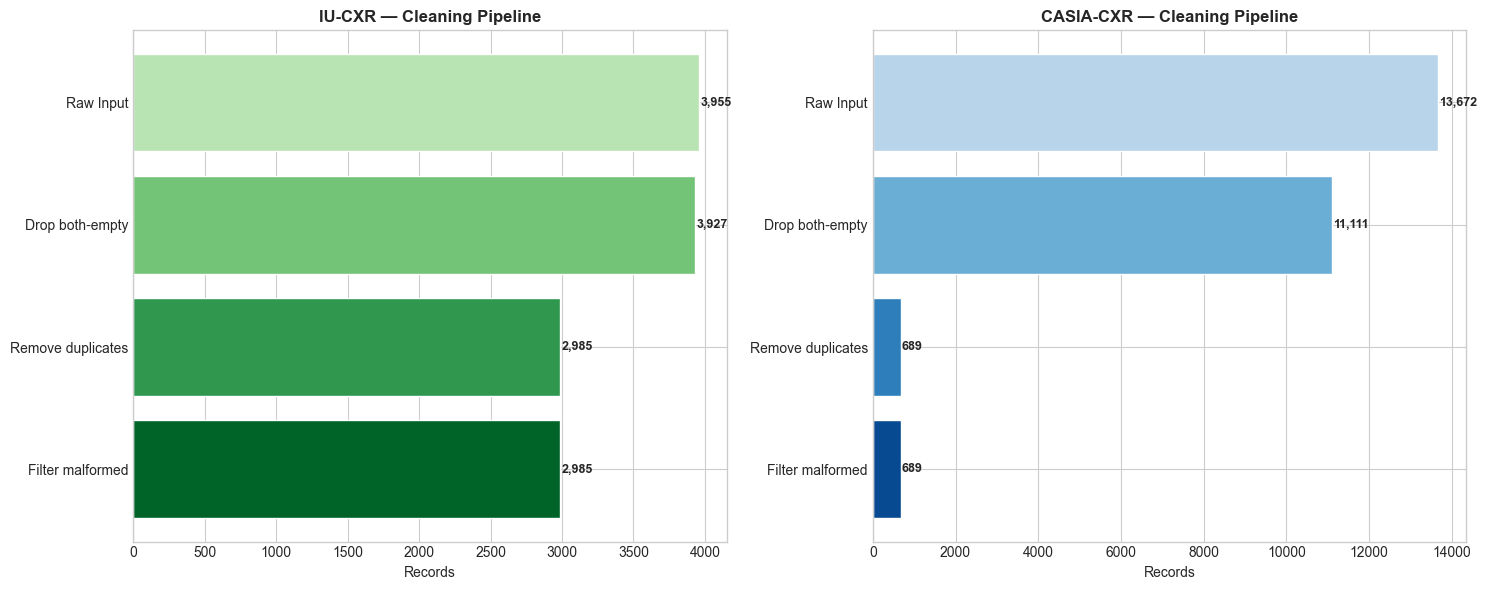

Saved: ../outputs/07_cleaning_pipeline.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── IU-CXR funnel ───────────────────────────────────────────────────────────
ax = axes[0]
iu_log_df = pd.DataFrame(iu_log, columns=['Step', 'After', 'Removed', 'Reason'])
steps  = iu_log_df['Step'].tolist()
counts = iu_log_df['After'].tolist()
colors = plt.cm.Greens(np.linspace(0.3, 0.9, len(steps)))
bars = ax.barh(range(len(steps)), counts, color=colors, edgecolor='white')
ax.set_yticks(range(len(steps)))
ax.set_yticklabels(steps)
ax.set_xlabel('Records')
ax.set_title('IU-CXR — Cleaning Pipeline', fontweight='bold')
for i, (c, b) in enumerate(zip(counts, bars)):
    ax.text(c + 15, i, f'{c:,}', va='center', fontweight='bold', fontsize=9)
ax.invert_yaxis()

# ── CASIA-CXR funnel ────────────────────────────────────────────────────────
ax = axes[1]
ca_log_df = pd.DataFrame(ca_log, columns=['Step', 'After', 'Removed', 'Reason'])
steps  = ca_log_df['Step'].tolist()
counts = ca_log_df['After'].tolist()
colors = plt.cm.Blues(np.linspace(0.3, 0.9, len(steps)))
bars = ax.barh(range(len(steps)), counts, color=colors, edgecolor='white')
ax.set_yticks(range(len(steps)))
ax.set_yticklabels(steps)
ax.set_xlabel('Records')
ax.set_title('CASIA-CXR — Cleaning Pipeline', fontweight='bold')
for i, (c, b) in enumerate(zip(counts, bars)):
    ax.text(c + 15, i, f'{c:,}', va='center', fontweight='bold', fontsize=9)
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('../outputs/07_cleaning_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../outputs/07_cleaning_pipeline.png")

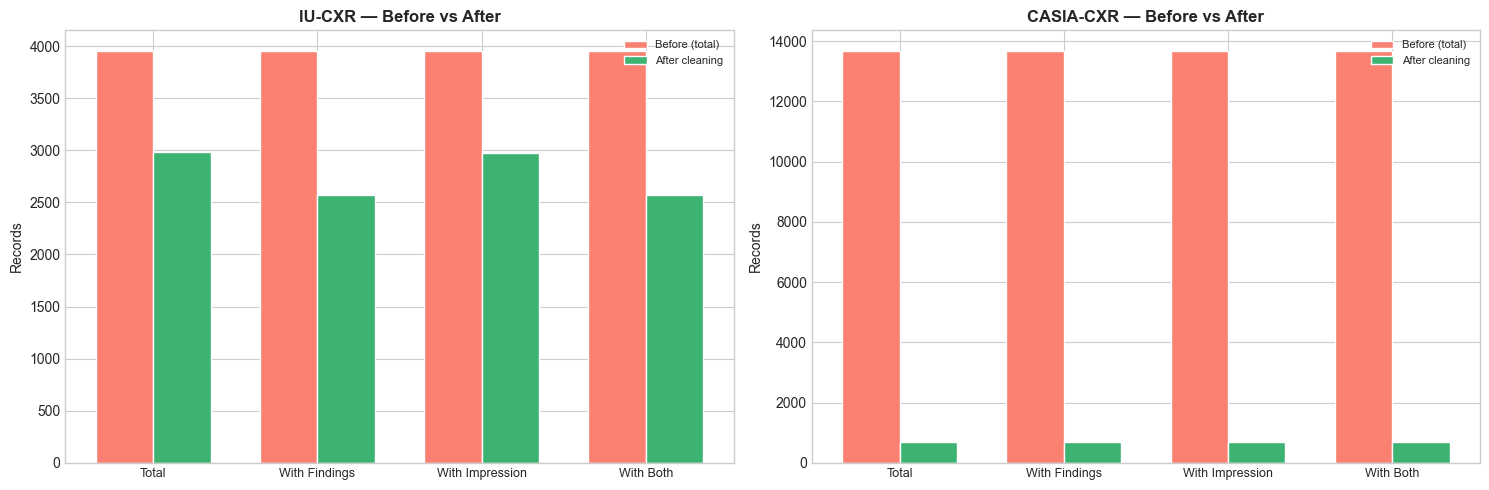

Saved: ../outputs/07b_before_after.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, name, df, initial, fc, ic in [
    (axes[0], 'IU-CXR',    df_iu, iu_initial, 'findings_clean', 'impression_clean'),
    (axes[1], 'CASIA-CXR', df_ca, ca_initial, 'findings_clean', 'impression_clean'),
]:
    cats = ['Total', 'With Findings', 'With Impression', 'With Both']
    f_ne = (df[fc].fillna('').astype(str).str.strip() != '').sum()
    i_ne = (df[ic].fillna('').astype(str).str.strip() != '').sum()
    b_ne = ((df[fc].fillna('').astype(str).str.strip() != '') &
            (df[ic].fillna('').astype(str).str.strip() != '')).sum()
    after = [len(df), f_ne, i_ne, b_ne]

    x = np.arange(len(cats))
    w = 0.35
    ax.bar(x - w/2, [initial]*4, w, label='Before (total)', color='salmon',  edgecolor='white')
    ax.bar(x + w/2, after,        w, label='After cleaning',  color='mediumseagreen', edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(cats, fontsize=9)
    ax.set_ylabel('Records')
    ax.set_title(f'{name} — Before vs After', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/07b_before_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ../outputs/07b_before_after.png")

## Step 9: Save Cleaned Datasets

Two separate CSVs — one per dataset — so downstream notebooks can load
whichever they need.

In [16]:
iu_save_cols = [
    'uid', 'pmc_id', 'filename',
    'findings', 'impression', 'indication', 'comparison',
    'findings_clean', 'impression_clean', 'indication_clean',
    'mesh_major', 'mesh_minor', 'num_images', 'image_ids',
    'dataset_source',
]
# Keep only columns that actually exist (EDA-computed columns are optional)
iu_save_cols = [c for c in iu_save_cols if c in df_iu.columns]

# Also carry forward any EDA-computed columns that exist
eda_cols = [c for c in df_iu.columns if c not in iu_save_cols
            and c not in ('combined_text',)]
iu_save_cols += eda_cols

df_iu[iu_save_cols].to_csv('../data/iu_cxr_cleaned.csv', index=False)
print(f"Saved: ../data/iu_cxr_cleaned.csv")
print(f"  Shape : {df_iu[iu_save_cols].shape}")
print(f"  Columns: {iu_save_cols}")

Saved: ../data/iu_cxr_cleaned.csv
  Shape : (2985, 36)
  Columns: ['uid', 'pmc_id', 'filename', 'findings', 'impression', 'indication', 'comparison', 'findings_clean', 'impression_clean', 'indication_clean', 'mesh_major', 'mesh_minor', 'num_images', 'image_ids', 'dataset_source', 'findings_word_count', 'impression_word_count', 'indication_word_count', 'total_word_count', 'findings_char_count', 'impression_char_count', 'findings_sentence_count', 'impression_sentence_count', 'is_normal', 'pathology_categories', 'has_Normal', 'has_Cardiomegaly', 'has_Opacity/Mass', 'has_Atelectasis', 'has_Pleural Effusion', 'has_Pneumonia', 'has_Emphysema/COPD', 'has_Edema', 'has_xxxx', 'avg_sentence_len', 'num_pathologies']


In [17]:
ca_save_cols = [
    'uid', 'image_id', 'patient_id', 'image_dir', 'study_date',
    'patient_age', 'patient_gender', 'patient_position',
    'position_view', 'projection', 'projection_method',
    'image_width', 'image_height', 'report_id',
    'findings', 'impression', 'indication', 'comparison',
    'findings_clean', 'impression_clean', 'indication_clean',
    'pathology_label',
    'dataset_source',
]
ca_save_cols = [c for c in ca_save_cols if c in df_ca.columns]

df_ca[ca_save_cols].to_csv('../data/casia_cxr_cleaned.csv', index=False)
print(f"Saved: ../data/casia_cxr_cleaned.csv")
print(f"  Shape : {df_ca[ca_save_cols].shape}")
print(f"  Columns: {ca_save_cols}")

Saved: ../data/casia_cxr_cleaned.csv
  Shape : (689, 23)
  Columns: ['uid', 'image_id', 'patient_id', 'image_dir', 'study_date', 'patient_age', 'patient_gender', 'patient_position', 'position_view', 'projection', 'projection_method', 'image_width', 'image_height', 'report_id', 'findings', 'impression', 'indication', 'comparison', 'findings_clean', 'impression_clean', 'indication_clean', 'pathology_label', 'dataset_source']


In [18]:
print("=" * 65)
print("  Notebook 02 complete — both datasets cleaned and saved.")
print(f"  IU-CXR   : {len(df_iu):>6,} records  ->  ../data/iu_cxr_cleaned.csv")
print(f"  CASIA-CXR : {len(df_ca):>6,} records  ->  ../data/casia_cxr_cleaned.csv")
print("=" * 65)

  Notebook 02 complete — both datasets cleaned and saved.
  IU-CXR   :  2,985 records  ->  ../data/iu_cxr_cleaned.csv
  CASIA-CXR :    689 records  ->  ../data/casia_cxr_cleaned.csv
